# Joint inference of 6 ABM parameters (CT vs binary)

Extends the CT-surveillance inference from 2 parameters (beta, t_exposed) to 6, following the
model-free screen in `param_screen.ipynb` (all individually carry signal). Trains both
the CT-histogram and binary-count workflows, runs recovery/calibration diagnostics, and
estimates the information
gain `I(theta;X|d) = E_X[KL(p(theta|X,d) || p(theta))]`, `Delta(d) = I_ct - I_bin` -- now
over a 6-dimensional theta.

`X` is the **survey** stream (`source = 0`): the active random-surveillance positives.
Diagnostic care-seeking (`source = 1`) runs in the background (suppressing the epidemic)
but is not part of the analysed data. This is one fixed testing design `d`; for the design
sweep see `run_design_sweep.py`.

Two questions beyond the 2-parameter case:
1. **Separability**: the screen holds every other parameter fixed, so it can't see
   confounding. Watch per-parameter recovery and the pairwise posterior -- especially
   **t_exposed vs t_presym** (both load on epidemic timing) and **beta vs
   quarantine_compliance** (both scale effective transmission, one directly and one by
   removing infectious people from mixing) as the prime confounding suspects.
2. **Does the binary signal lose more on 6 parameters than on 2?** The screen suggested the
   extra parameters act via prevalence/timing (binary-visible) rather than the CT-value
   distribution, so Delta may not grow much despite the higher-dimensional theta.

**Priors** (COVID-like wildtype; see forward_pass.h for meanings/units). All have **full
support** -- lognormal for the positive params, logit-normal for the probabilities -- so the
flow's posterior never overshoots into a zero-density region, keeping the KL/MI finite
without masking (unlike a hard-bounded uniform):

| param | forward_pass key | prior | ~95% range |
|---|---|---|---|
| beta | `beta` | lognormal(median 1.0, sigma 0.5) | [0.38, 2.7] |
| t_exposed | `t_exposed` | lognormal(median 5.0, sigma 0.4) | [2.3, 11] |
| t_presym | `time_presymptomatic` | lognormal(median 1.5, sigma 0.5) | [0.56, 4.0] |
| t_asym | `time_asymptomatic_recovery` | lognormal(median 8.0, sigma 0.25) | [4.9, 13] |
| p_sym | `symptom_prob` | logit-normal(median 0.6, sigma 0.5) | [0.35, 0.80] |
| p_quar | `quarantine_compliance` | logit-normal(median 0.6, sigma 0.5) | [0.35, 0.80] |

In [18]:
import os

if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"  # set before importing keras

import time
import warnings
from collections.abc import Collection

import matplotlib.pyplot as plt
import numpy as np
import keras
import bayesflow as bf
from scipy import stats

from memilio.simulation.abm import ABMPopulation, TestingBudget
from abm_batch import run_batch

In [19]:
SIM_DAYS, N_CT_BINS = 30, 41   # forward_pass() survey-stream histogram layout
SURVEY = 0                     # TestSource tag: active surveillance (the analysed stream X)
DIAGNOSTIC = 1                 # TestSource tag: symptomatic care-seeking

def to_city_histogram(out, sim_days=SIM_DAYS, n_bins=N_CT_BINS,
                      sources: Collection[int] = frozenset({SURVEY})):
    """forward_pass()'s positives table -> a fixed (sim_days, n_bins) city-wide CT-value
    histogram of the pooled `sources` streams: {0}=survey, {1}=diagnostic, {0, 1}=both.
    out['positives'] columns are [day, person_id, age, location, ct, source]."""
    city = np.zeros((sim_days, n_bins))
    pos = out["positives"]
    if pos.shape[0]:
        m = np.isin(pos[:, 5], list(sources))
        days = np.round(pos[m, 0]).astype(int)
        cts = np.clip(np.round(pos[m, 4]).astype(int), 0, n_bins - 1)
        valid = (days >= 0) & (days < sim_days)
        if not valid.all():
            warnings.warn(f"{(~valid).sum()} positive(s) had day outside [0, {sim_days}) and were dropped.")
        np.add.at(city, (days[valid], cts[valid]), 1)
    return city

def to_bin_counts(city_hist):
    """X_bin = g(X_CT): detected positives per day (every bin is a positive-CT bin)."""
    return city_hist.sum(axis=-1)

In [ ]:
RNG = np.random.default_rng(2025)
POPULATION = ABMPopulation(total_population=100_000)
# event_budget_fraction is the fraction sampled PER surveillance event; period 1 = every day.
DESIGN = TestingBudget(event_budget_fraction=0.1, test_period_days=1)

PARAM_KEYS = ["beta", "t_exposed", "time_presymptomatic", "time_asymptomatic_recovery", "symptom_prob",
             "quarantine_compliance"]
PAR_NAMES = [r"$\beta$", r"$t_\mathrm{exp}$", r"$t_\mathrm{presym}$", r"$t_\mathrm{asym}$", r"$p_\mathrm{sym}$",
            r"$p_\mathrm{quar}$"]

# Full-support priors, chosen so the flow's posterior never overshoots into a zero-density
# region (which would make KL/MI infinite and force masking): positive params -> lognormal
# (support (0, inf)), symptom_prob/quarantine_compliance -> logit-normal (support (0, 1)). Both
# keep every simulator input valid, unlike a raw Gaussian. numpy's lognormal(mean, sigma)
# parameterises the underlying normal, matching scipy.stats.lognorm(s=sigma, scale=exp(mean)).
BETA_S,  BETA_SCALE  = 0.5,  1.0   # median 1.0
TEXP_S, TEXP_SCALE = 0.4,  5.0   # median 5.0  (~95% in [2.3, 11])
TPRE_S,  TPRE_SCALE  = 0.5,  1.5   # median 1.5  (~95% in [0.56, 4.0])
TASYM_S, TASYM_SCALE = 0.25, 8.0   # median 8.0  (~95% in [4.9, 13])
PSYM_MU, PSYM_SIGMA  = np.log(0.6 / 0.4), 0.5  # logit-normal, median 0.6 (~[0.35, 0.80])
# Was a fixed quarantine_compliance=0.0 (no isolation) baseline; now inferred like every other
# theta, same logit-normal shape as symptom_prob -- see abm_inference.py's PRIOR_QCOMP_MU/SIGMA.
QCOMP_MU, QCOMP_SIGMA = np.log(0.6 / 0.4), 0.5  # logit-normal, median 0.6 (~[0.35, 0.80])

def prior():
    """One joint draw; the returned dict IS a forward_pass params dict (all 6 keys recognised)."""
    z_sym = RNG.normal(PSYM_MU, PSYM_SIGMA)
    z_qcomp = RNG.normal(QCOMP_MU, QCOMP_SIGMA)
    return {
        "beta":                       RNG.lognormal(np.log(BETA_SCALE),  BETA_S),
        "t_exposed":                      RNG.lognormal(np.log(TEXP_SCALE), TEXP_S),
        "time_presymptomatic":        RNG.lognormal(np.log(TPRE_SCALE),  TPRE_S),
        "time_asymptomatic_recovery": RNG.lognormal(np.log(TASYM_SCALE), TASYM_S),
        "symptom_prob":               1.0 / (1.0 + np.exp(-z_sym)),  # expit(N(PSYM_MU, PSYM_SIGMA))
        "quarantine_compliance":      1.0 / (1.0 + np.exp(-z_qcomp)),  # expit(N(QCOMP_MU, QCOMP_SIGMA))
    }

def _logitnorm_logpdf(p, mu, sigma):
    """log-density of a logit-normal at p in (0,1); -inf outside (0,1) (e.g. flow overshoots)."""
    p = np.asarray(p, dtype=float)
    out = np.full(p.shape, -np.inf)
    m = (p > 0.0) & (p < 1.0)
    z = np.log(p[m] / (1.0 - p[m]))
    out[m] = stats.norm.logpdf(z, loc=mu, scale=sigma) - np.log(p[m]) - np.log1p(-p[m])
    return out

def prior_log_prob(**params):
    """log p(theta) under prior()'s exact independent sampling distributions (original space).
    Each factor is -inf outside its support (lognorm for x<=0, logit-normal for p not in (0,1)),
    which the MI estimator masks."""
    return (stats.lognorm.logpdf(params["beta"],                       s=BETA_S,  scale=BETA_SCALE)
            + stats.lognorm.logpdf(params["t_exposed"],                      s=TEXP_S, scale=TEXP_SCALE)
            + stats.lognorm.logpdf(params["time_presymptomatic"],        s=TPRE_S,  scale=TPRE_SCALE)
            + stats.lognorm.logpdf(params["time_asymptomatic_recovery"], s=TASYM_S, scale=TASYM_SCALE)
            + _logitnorm_logpdf(params["symptom_prob"], PSYM_MU, PSYM_SIGMA)
            + _logitnorm_logpdf(params["quarantine_compliance"], QCOMP_MU, QCOMP_SIGMA))

In [21]:
def make_dataset(n, population, design, max_workers=None, show_progress=True):
    """n joint prior draws run in parallel; returns per-parameter (n,1) arrays plus BOTH the CT
    histogram and its binary coarsening, all from the SAME simulations (paired CT/binary data)."""
    draws = [prior() for _ in range(n)]  # each draw is already a forward_pass params dict
    outs = run_batch(draws, population, design, max_workers=max_workers, show_progress=show_progress)
    city_hists = np.stack([to_city_histogram(o) for o in outs])
    data = {k: np.array([d[k] for d in draws], dtype=np.float64).reshape(-1, 1) for k in PARAM_KEYS}
    data["histogram_ct"] = city_hists
    data["histogram_bin"] = to_bin_counts(city_hists)
    data["n_ever_infected"] = np.array([o["n_ever_infected"][0, 0] for o in outs], dtype=np.float64)
    return data

print("Simulating training data...")
raw_train = make_dataset(2500, POPULATION, DESIGN)  
print("Simulating validation data...")
raw_val = make_dataset(500, POPULATION, DESIGN)
print(f"Training: {len(raw_train['beta'])}  |  Validation: {len(raw_val['beta'])}")

Simulating training data...


  0%|          | 0/2500 [00:00<?, ?sim/s]

Simulating validation data...


  0%|          | 0/500 [00:00<?, ?sim/s]

Training: 2500  |  Validation: 500


survey positives/sim: median 5349, IQR [4404, 6570]
n ever infected:      median 4792, IQR [3616, 6258]


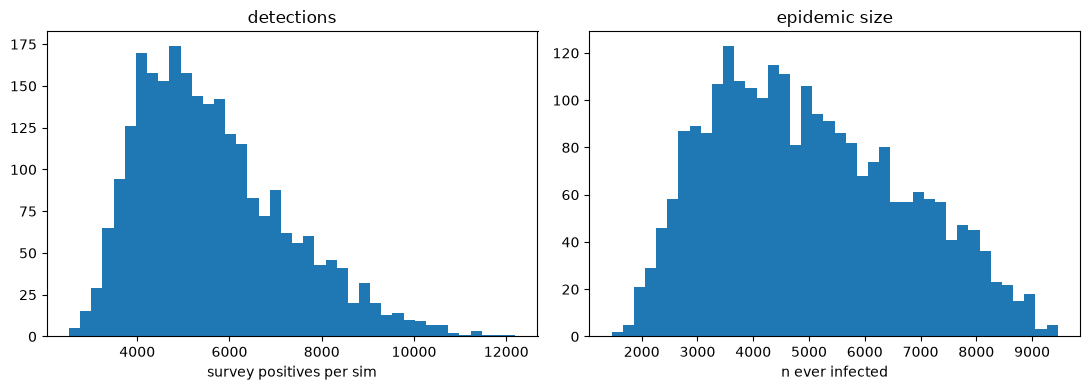

In [22]:
pos_per_sim = raw_train["histogram_ct"].sum(axis=(1, 2))
n_inf = raw_train["n_ever_infected"]
print(f"survey positives/sim: median {np.median(pos_per_sim):.0f}, "
      f"IQR [{np.percentile(pos_per_sim, 25):.0f}, {np.percentile(pos_per_sim, 75):.0f}]")
print(f"n ever infected:      median {np.median(n_inf):.0f}, "
      f"IQR [{np.percentile(n_inf, 25):.0f}, {np.percentile(n_inf, 75):.0f}]")
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
a0.hist(pos_per_sim, bins=40); a0.set_xlabel("survey positives per sim"); a0.set_title("detections")
a1.hist(n_inf, bins=40); a1.set_xlabel("n ever infected"); a1.set_title("epidemic size")
fig.tight_layout(); plt.show()

In [23]:
class GRU(bf.networks.SummaryNetwork):
    def __init__(self, hidden_dim=128, summary_dim=16, dropout=0.2, recurrent_dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.gru1 = keras.layers.GRU(hidden_dim, return_sequences=True,
                                     dropout=dropout, recurrent_dropout=recurrent_dropout)
        self.gru2 = keras.layers.GRU(hidden_dim, dropout=dropout, recurrent_dropout=recurrent_dropout)
        self.summary_stats = keras.layers.Dense(summary_dim)

    def call(self, time_series, **kwargs):
        training = kwargs.get("stage") == "training"
        x = self.gru1(time_series, training=training)
        x = self.gru2(x, training=training)
        return self.summary_stats(x)

In [ ]:
# Two capacity-matched workflows over all 6 parameters: identical GRU config so a measured
# Delta reflects the representations' information content, not network capacity.
def build_workflow(summary_key):
    adapter = (
        bf.adapters.Adapter()
        .convert_dtype("float64", "float32")
        .as_time_series(summary_key)
        .concatenate(PARAM_KEYS, into="inference_variables")
        .rename(summary_key, "summary_variables")
        .log(["inference_variables", "summary_variables"], p1=True)
    )
    return bf.BasicWorkflow(
        adapter=adapter,
        inference_network=bf.networks.CouplingFlow(),
        summary_network=GRU(),
        standardize="inference_variables",  # 6 params on very different scales -> standardize
    )

workflow_ct = build_workflow("histogram_ct")
workflow_bin = build_workflow("histogram_bin")

#inference_variables must be (b, 6).
_slice = {k: v[:4] for k, v in raw_train.items()}
for name, wf in [("ct", workflow_ct), ("bin", workflow_bin)]:
    s = wf.adapter(_slice)
    print(f"{name:4s}  summary_variables: {s['summary_variables'].shape}  "
          f"inference_variables: {s['inference_variables'].shape}")

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True, start_from_epoch=50,
)
# BayesFlow sizes its default CosineDecay LR schedule to the `epochs` argument below, not to
# whenever EarlyStopping actually fires -- keep it close to the epoch count runs actually stop
# at (observed ~100-102 here with patience=15, start_from_epoch=50), or training gets cut off
# with the LR still near its peak, unannealed (this run stopped at 102/300 with LR still ~79%
# of its initial value -- consistent with the mid-training val_loss spikes in the loss curves).
TRAIN_EPOCHS = 120
print("Training CT workflow...")
history_ct = workflow_ct.fit_offline(
    data=raw_train, epochs=TRAIN_EPOCHS, batch_size=64, validation_data=raw_val, callbacks=[early_stop],
)
print("\nTraining binary workflow...")
history_bin = workflow_bin.fit_offline(
    data=raw_train, epochs=TRAIN_EPOCHS, batch_size=64, validation_data=raw_val, callbacks=[early_stop],
)

In [ ]:
f = bf.diagnostics.plots.loss(history_ct)
f.suptitle("Training loss -- CT histogram (6 params)", y=1.02)

f = bf.diagnostics.plots.loss(history_bin)
f.suptitle("Training loss -- Binary count (6 params)", y=1.02)

In [27]:
num_diag_samples = 1000
post_ct  = workflow_ct.sample(conditions=raw_val, num_samples=num_diag_samples)
post_bin = workflow_bin.sample(conditions=raw_val, num_samples=num_diag_samples)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 2.43 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 2.20 seconds.


In [ ]:
# Per-parameter recovery. A low r for one parameter (others high) flags it as weakly
# identified; a low r for a *pair* that individually screened well flags confounding.
f = bf.diagnostics.plots.recovery(post_ct, raw_val, variable_names=PAR_NAMES)
f.suptitle("Recovery -- CT histogram (6 params)", y=1.02)

f = bf.diagnostics.plots.recovery(post_bin, raw_val, variable_names=PAR_NAMES)
f.suptitle("Recovery -- Binary count (6 params)", y=1.02)

                             r_CT  r_binary  gap (CT - binary)
symptom_prob                0.333     0.092              0.241
time_presymptomatic         0.370     0.181              0.189
time_asymptomatic_recovery  0.380     0.243              0.137
t_exposed                   0.911     0.835              0.076
beta                        0.946     0.944              0.002


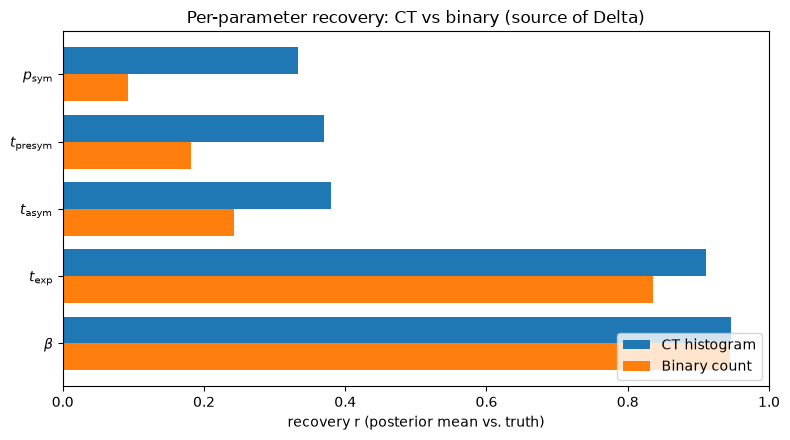

In [29]:
# Decompose the CT advantage (the Delta below) by parameter: recovery r is the correlation
# between the posterior mean and the ground truth, per workflow. Parameters where r_CT is
# clearly above r_binary are the ones the CT-value distribution pins down but the daily count
# can't -- i.e. where the extra information in Delta actually comes from.
from scipy.stats import pearsonr
import pandas as pd

def _recovery_r(post):
    return [pearsonr(raw_val[k].ravel(), post[k].mean(axis=1).ravel()).statistic for k in PARAM_KEYS]

rec = pd.DataFrame({"r_CT": _recovery_r(post_ct), "r_binary": _recovery_r(post_bin)}, index=PARAM_KEYS)
rec["gap (CT - binary)"] = rec["r_CT"] - rec["r_binary"]
rec = rec.sort_values("gap (CT - binary)", ascending=False)
print(rec.round(3).to_string())

# Grouped bars, parameters ordered by how much CT helps -- the source of Delta at a glance.
labels = [PAR_NAMES[PARAM_KEYS.index(k)] for k in rec.index]
y = np.arange(len(rec))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(y - 0.2, rec["r_CT"],     height=0.4, label="CT histogram")
ax.barh(y + 0.2, rec["r_binary"], height=0.4, label="Binary count")
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.invert_yaxis()  # biggest CT advantage on top
ax.set_xlim(0, 1)
ax.set_xlabel("recovery r (posterior mean vs. truth)")
ax.set_title("Per-parameter recovery: CT vs binary (source of Delta)")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

In [ ]:
f = bf.diagnostics.plots.calibration_ecdf(post_ct, raw_val, difference=True)
f.suptitle("ECDF calibration -- CT histogram (6 params)", y=1.02)

f = bf.diagnostics.plots.calibration_ecdf(post_bin, raw_val, difference=True)
f.suptitle("ECDF calibration -- Binary count (6 params)", y=1.02)

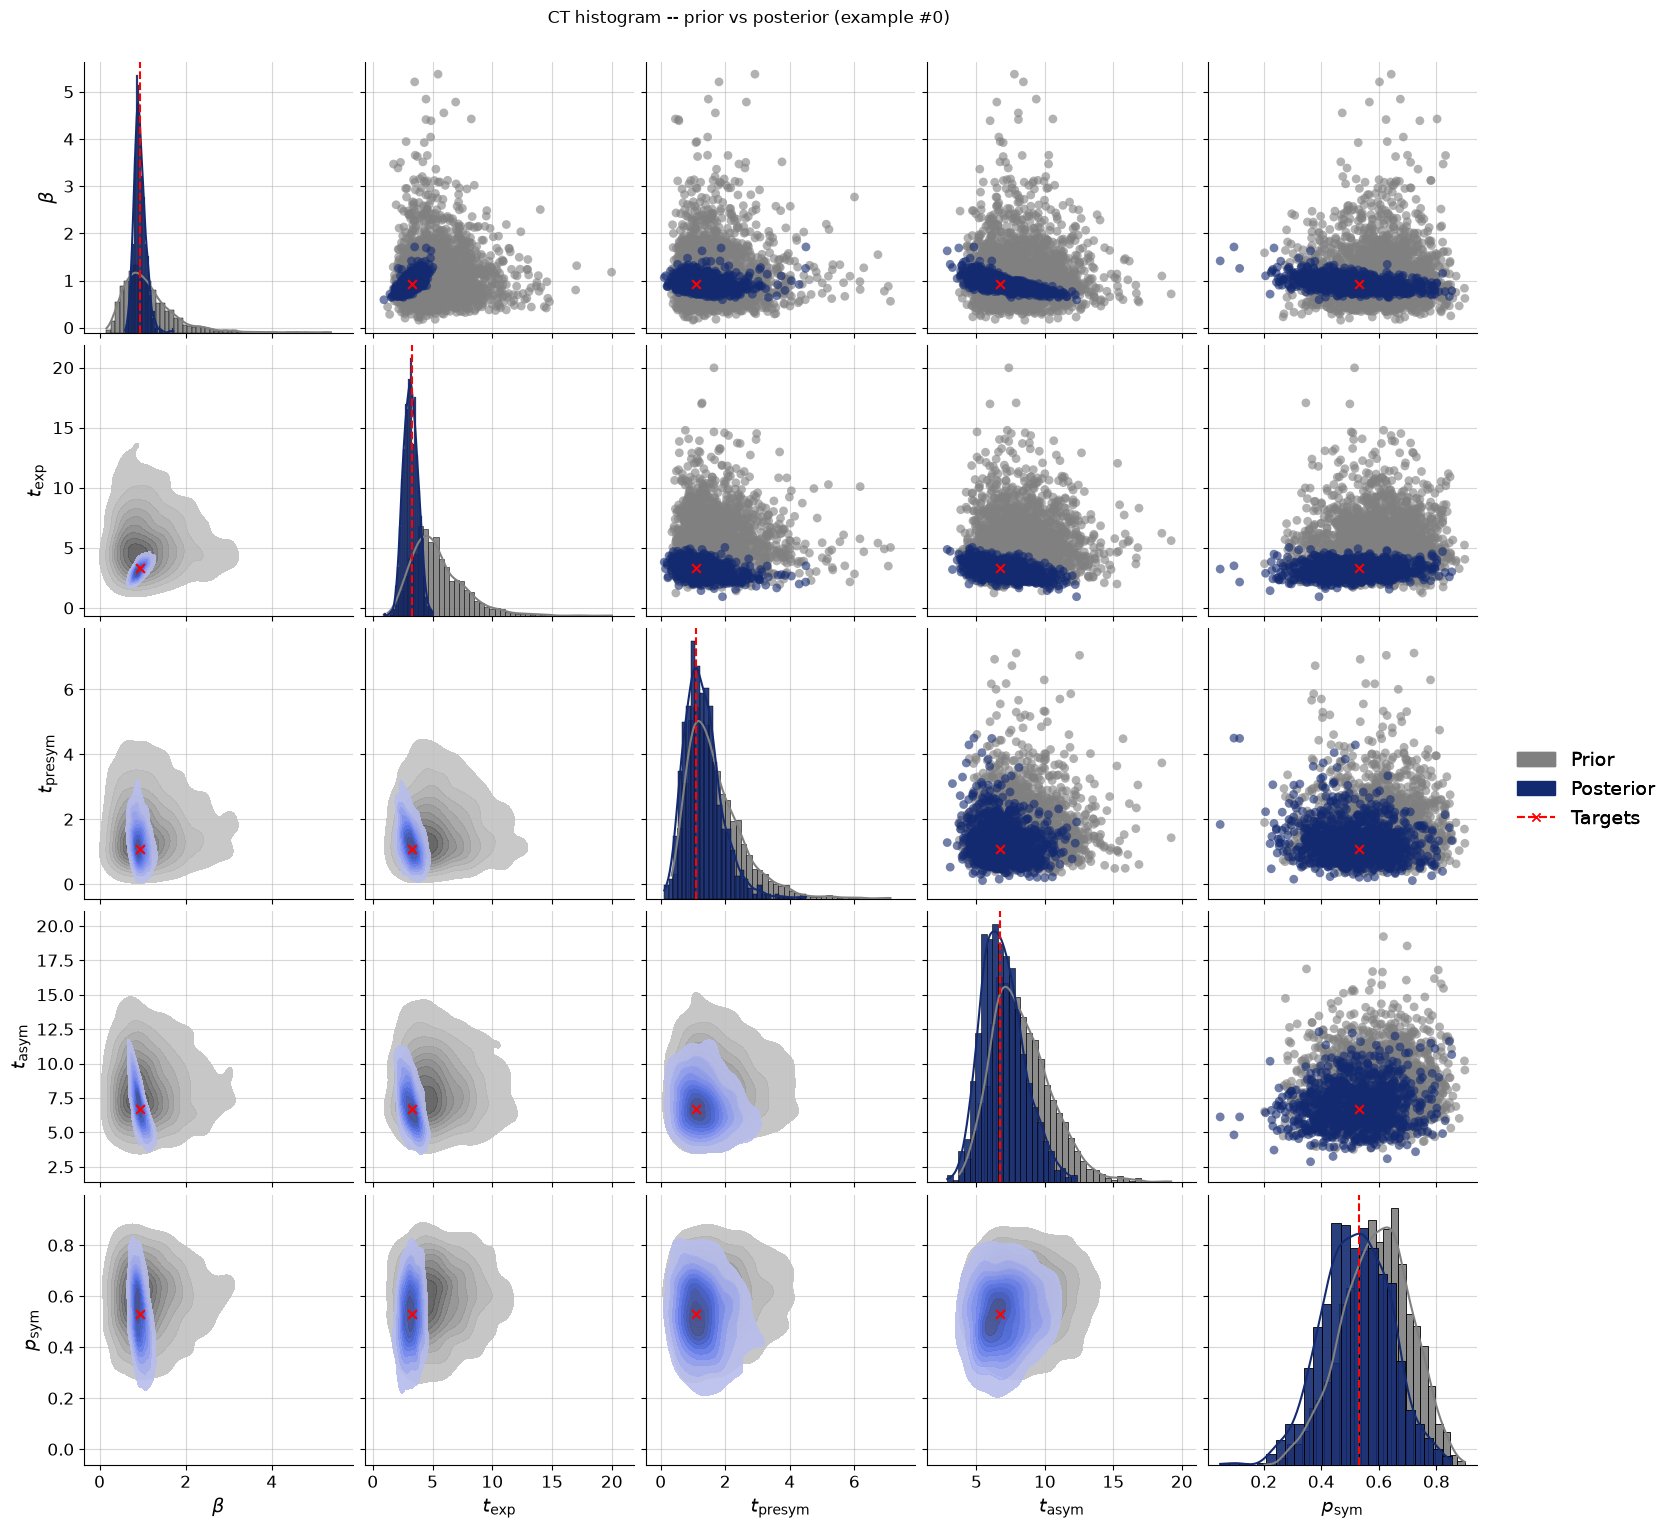

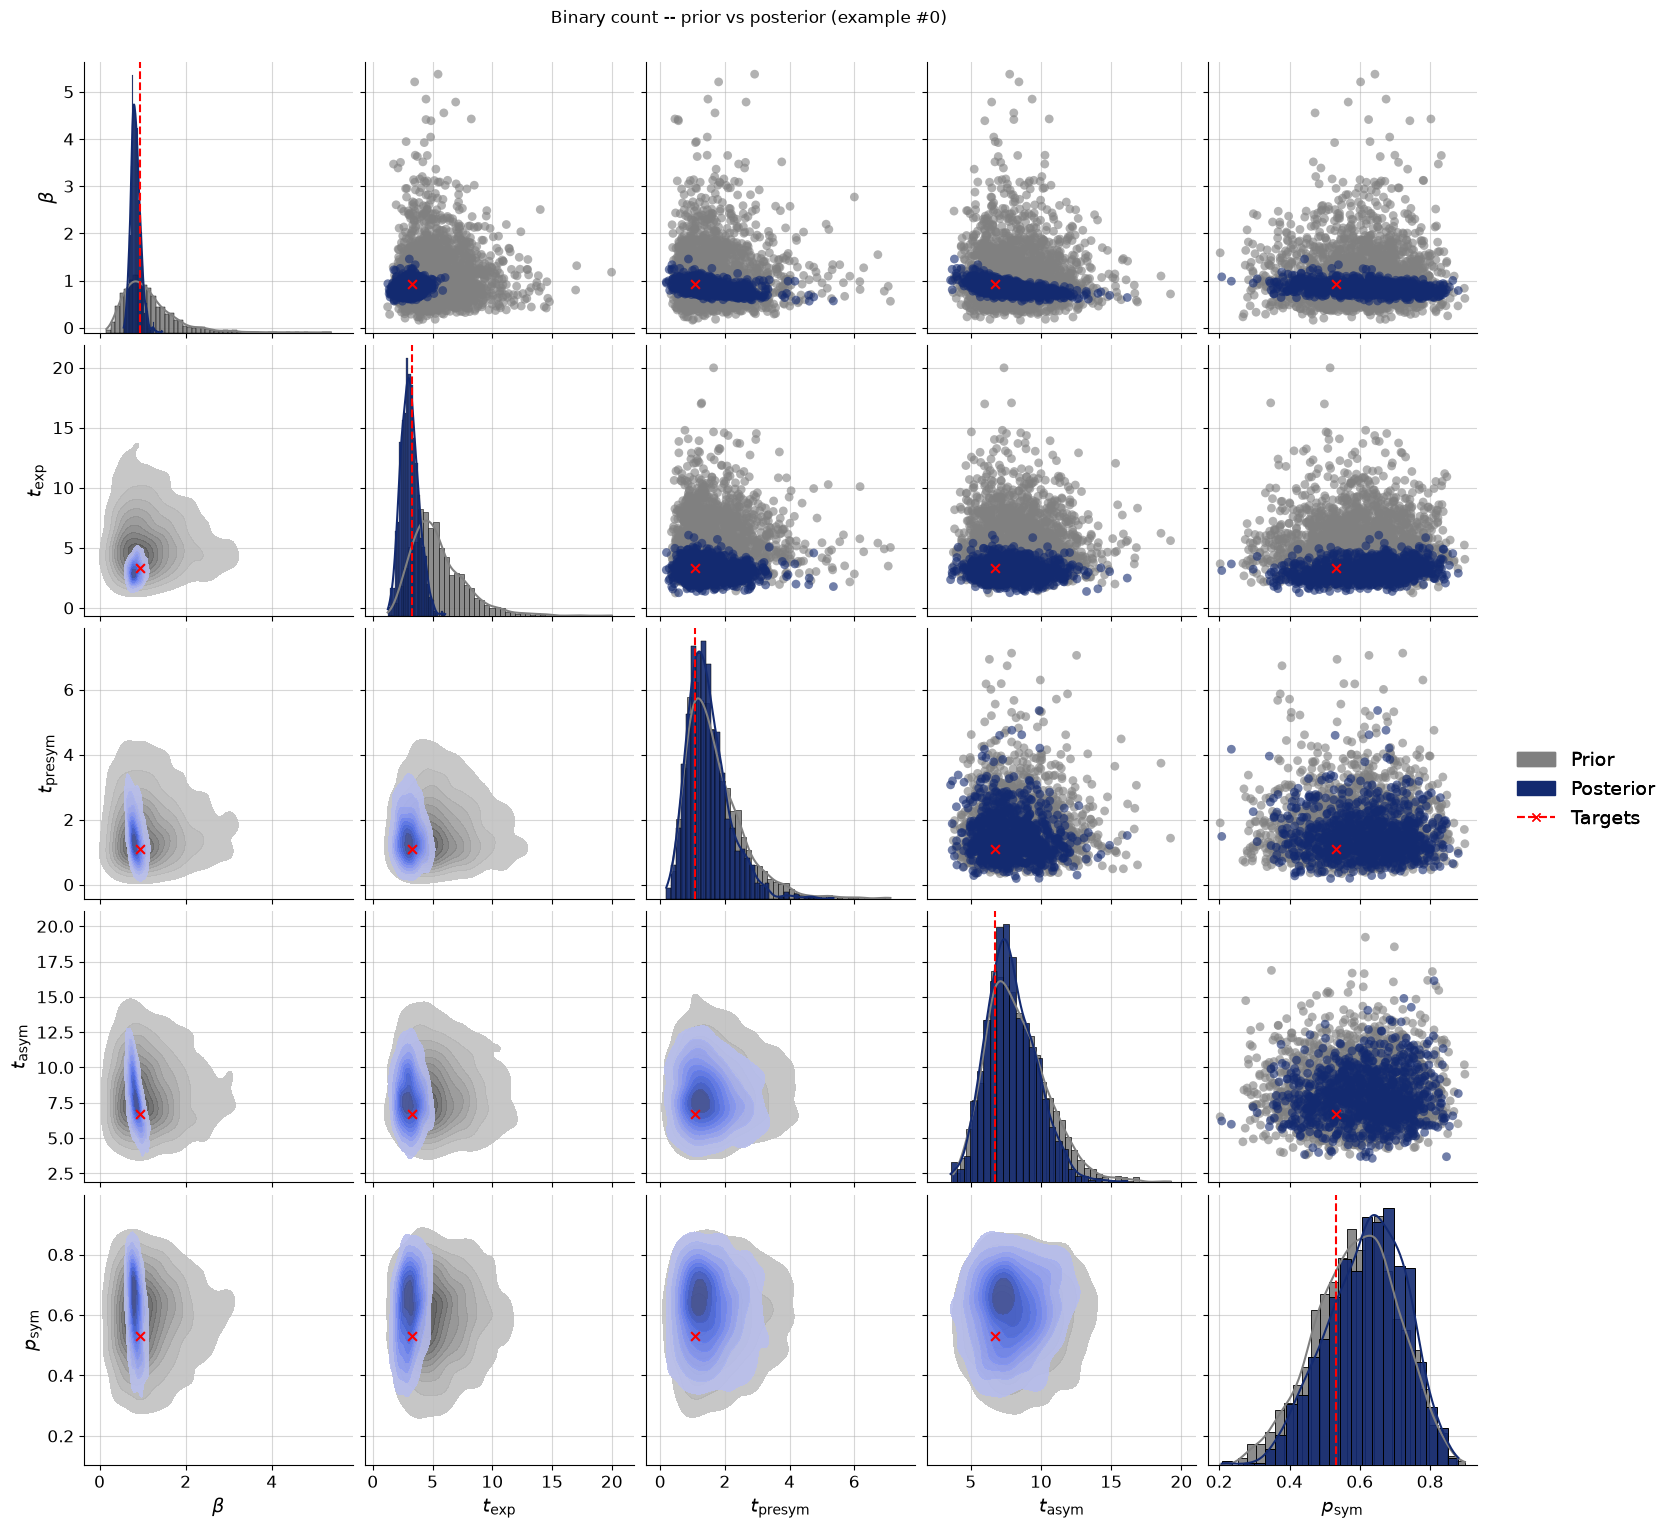

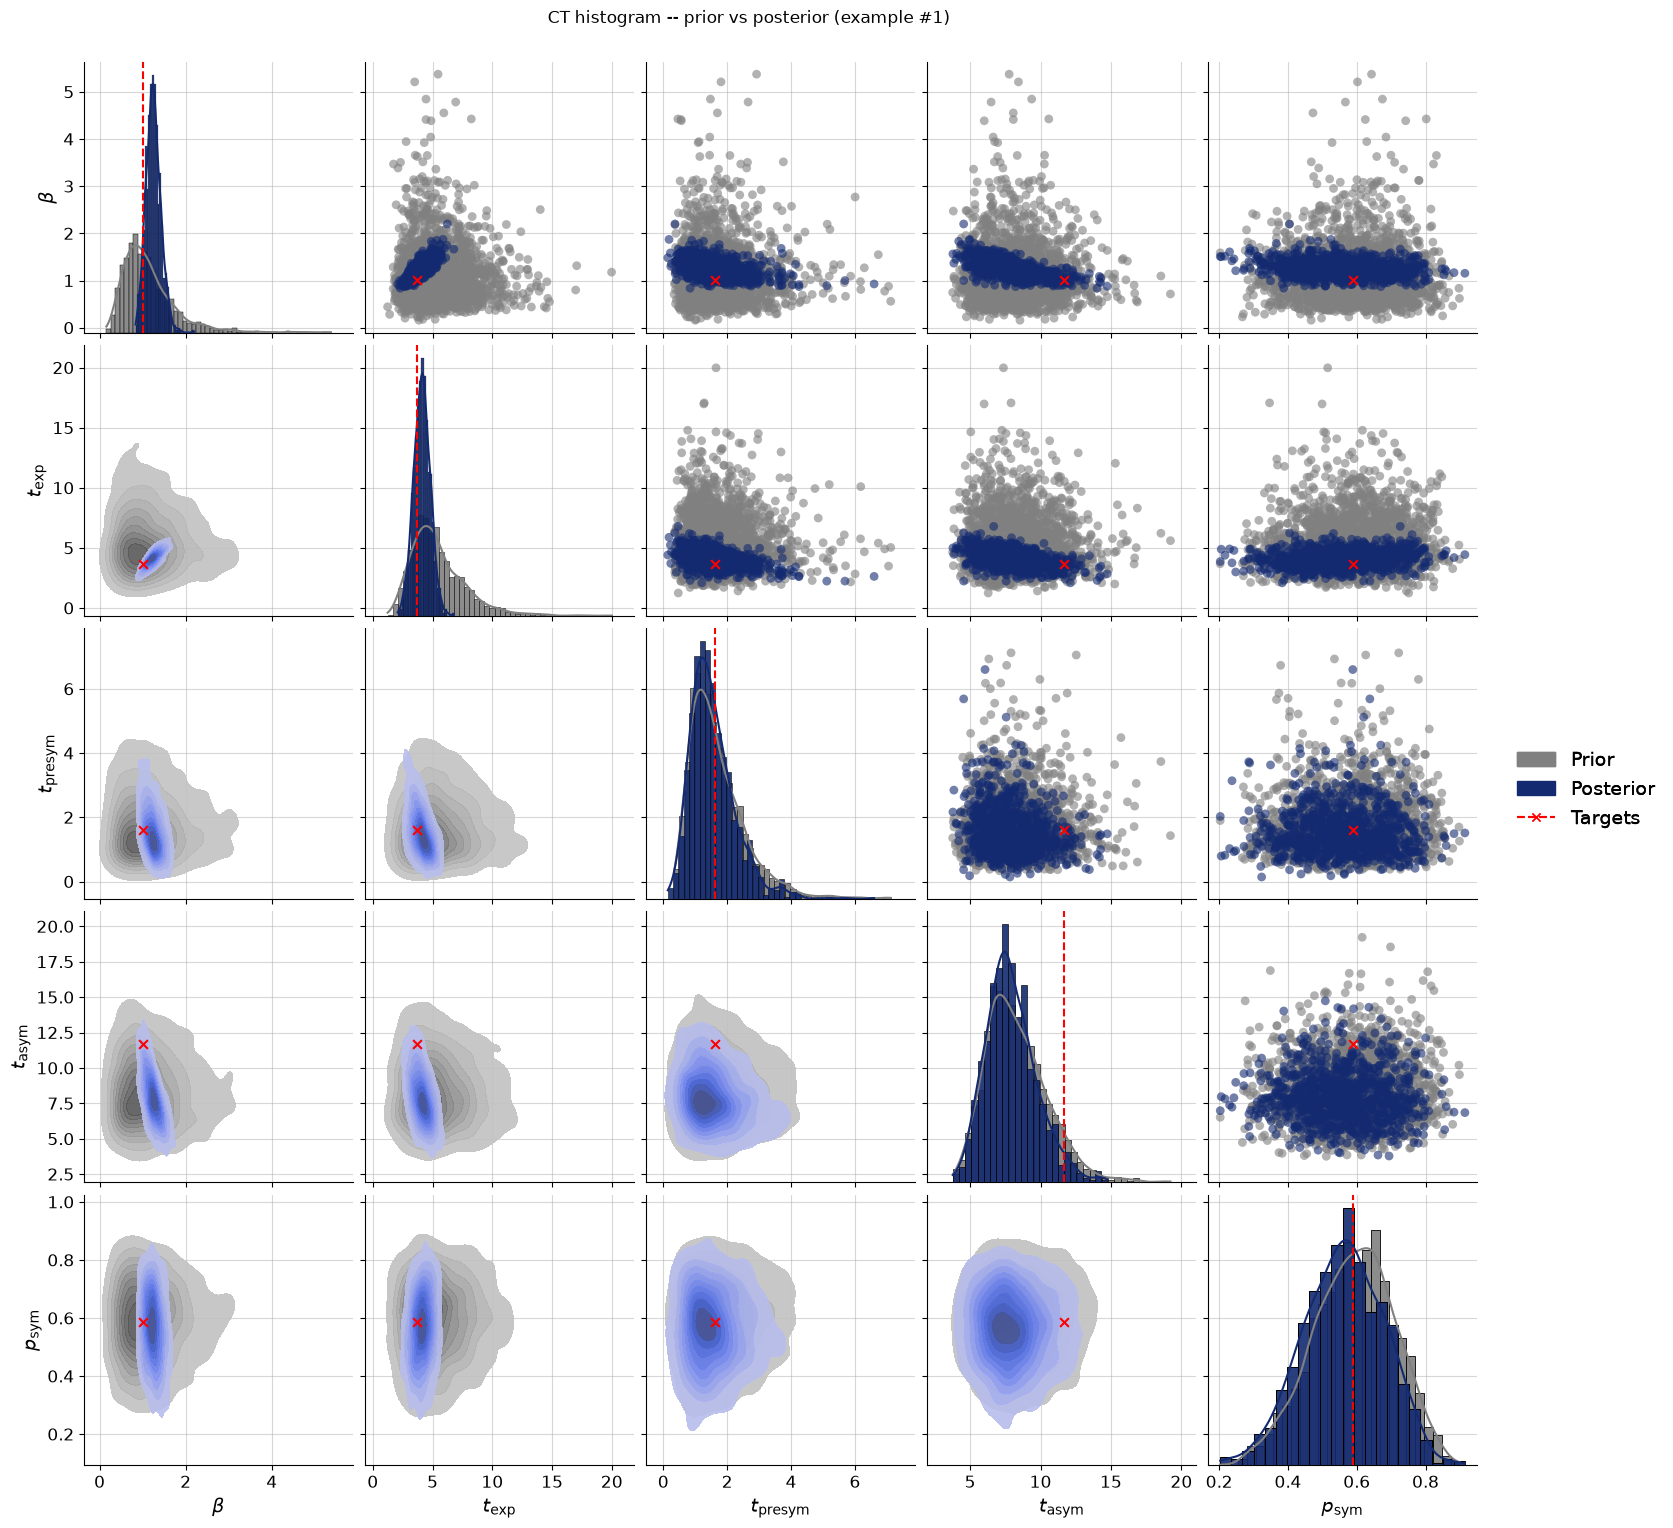

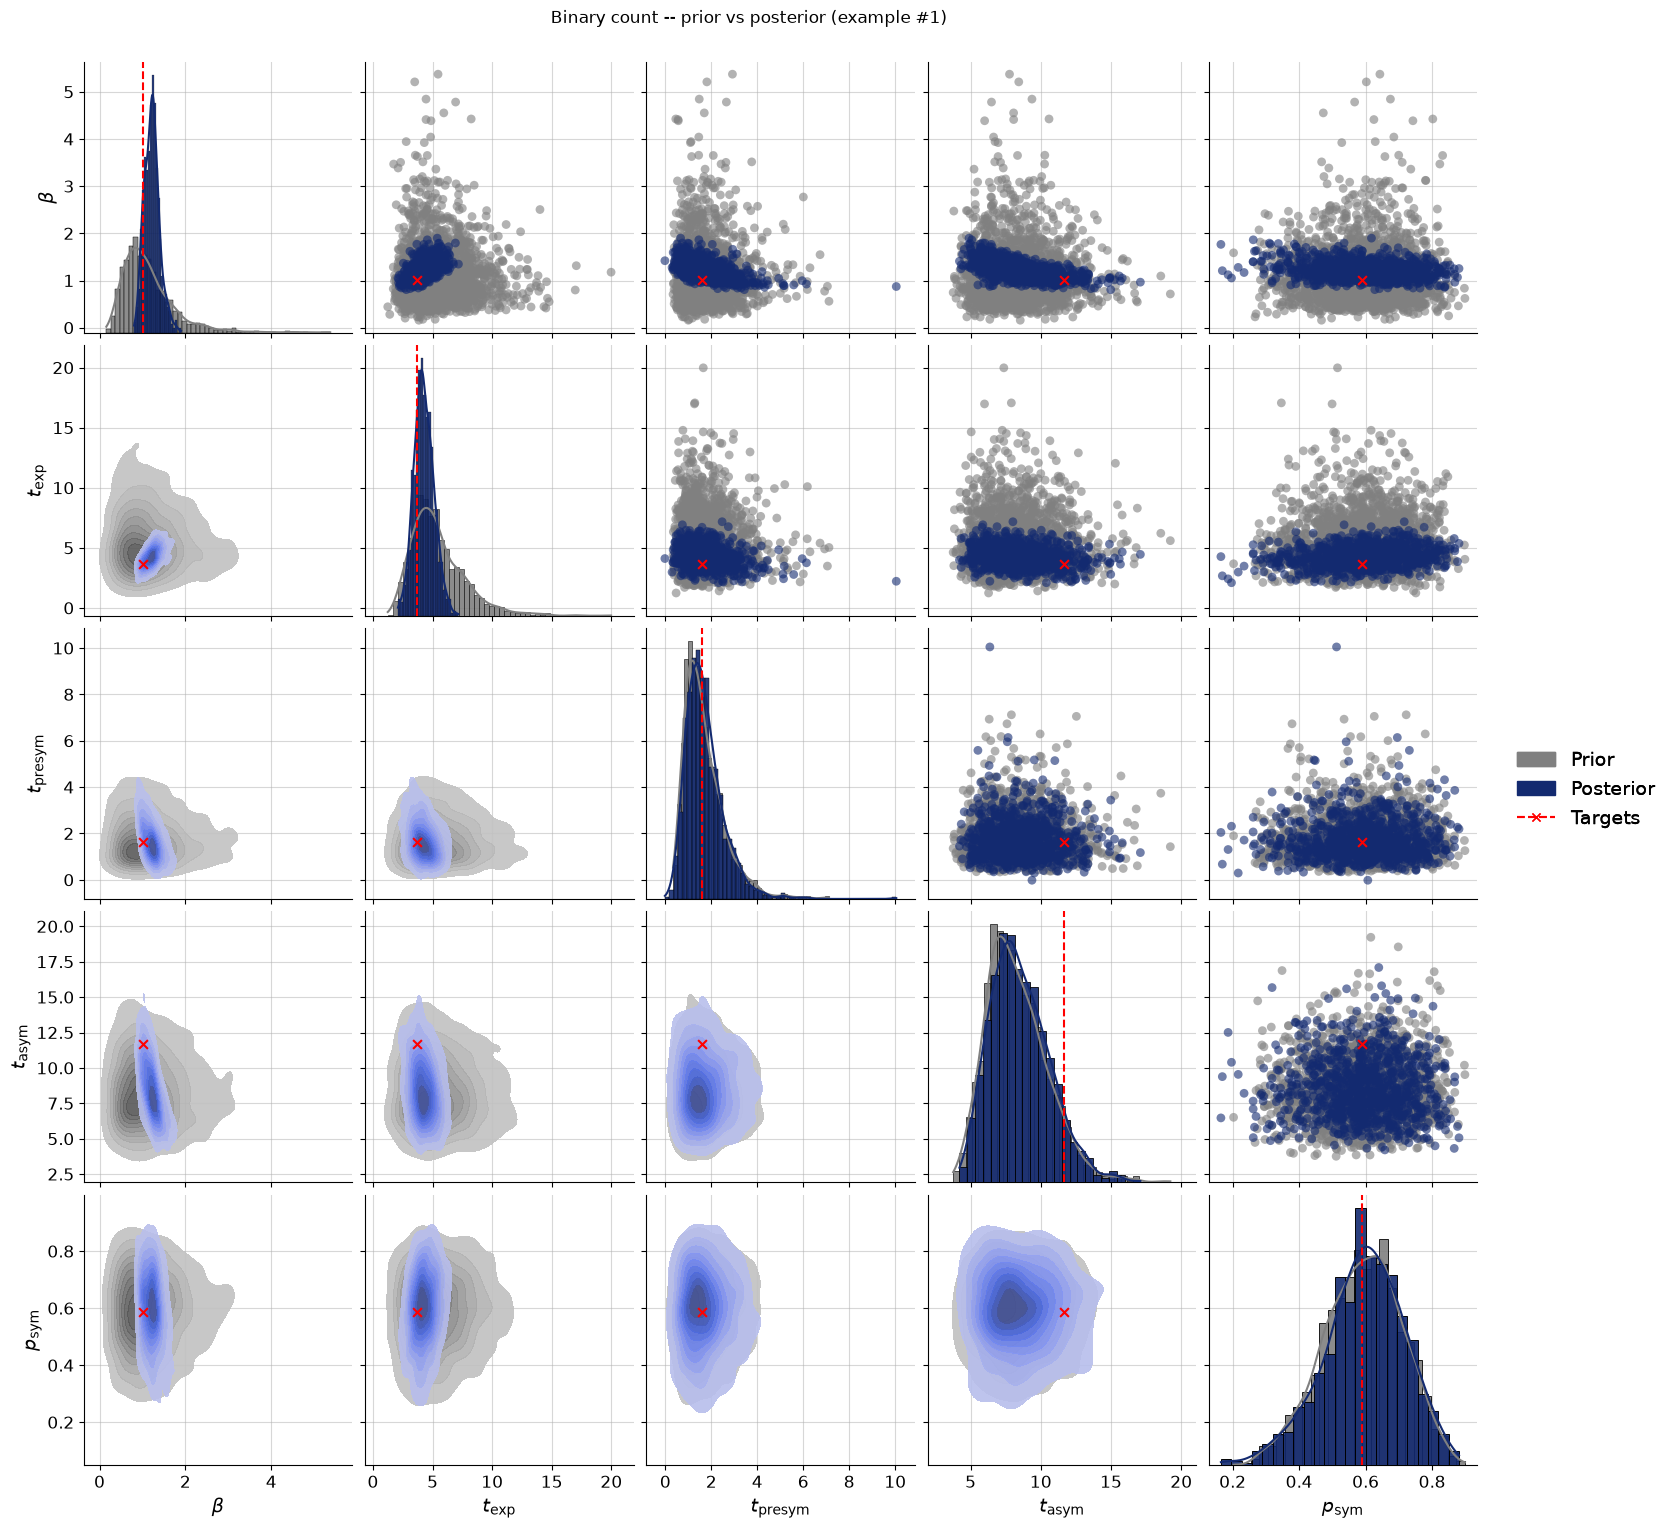

In [31]:
# Pairwise posterior -- the confounding check. A tight blob on the true point (red) is
# clean identification; a diagonal ridge in a panel means those two parameters trade off.
# Watch the t_exposed x t_presym panel especially.
prior_draws = {k: np.array([prior()[k] for _ in range(2000)]) for k in PARAM_KEYS}
for example_idx in [0, 1]:
    f = bf.diagnostics.plots.pairs_posterior(
        estimates=post_ct, targets=raw_val, priors=prior_draws, dataset_id=example_idx,
        variable_keys=PARAM_KEYS, variable_names=PAR_NAMES,
    )
    f.figure.suptitle(f"CT histogram -- prior vs posterior (example #{example_idx})", y=1.02)

    f = bf.diagnostics.plots.pairs_posterior(
        estimates=post_bin, targets=raw_val, priors=prior_draws, dataset_id=example_idx,
        variable_keys=PARAM_KEYS, variable_names=PAR_NAMES,
    )
    f.figure.suptitle(f"Binary count -- prior vs posterior (example #{example_idx})", y=1.02)

In [ ]:
def estimate_mutual_information(workflow, raw_val, x_key, num_posterior_samples=500, val_batch=32):
    """Direct Monte Carlo estimate of I(theta;X|d) = E_X[KL(p(theta|X,d) || p(theta))] over the
    6-dim theta. Returns (per-point KL, fraction of posterior samples outside the prior support).
    """
    n_val = len(raw_val["beta"])
    kls = np.empty(n_val)
    n_invalid, n_total = 0, 0
    for start in range(0, n_val, val_batch):
        idx = slice(start, min(start + val_batch, n_val))
        x_batch = raw_val[x_key][idx]
        post = workflow.sample(conditions={x_key: x_batch}, num_samples=num_posterior_samples)
        samples = {k: post[k].reshape(-1, 1) for k in PARAM_KEYS}
        x_tiled = np.repeat(x_batch, num_posterior_samples, axis=0)
        log_q = workflow.log_prob(data={x_key: x_tiled, **samples})
        log_q = log_q.reshape(x_batch.shape[0], num_posterior_samples)
        log_p = prior_log_prob(**samples).reshape(x_batch.shape[0], num_posterior_samples)
        diff = np.where(np.isfinite(log_q) & np.isfinite(log_p), log_q - log_p, np.nan)
        n_invalid += np.isnan(diff).sum()
        n_total += diff.size
        kls[idx] = np.nanmean(diff, axis=1)
    return kls, n_invalid / n_total

In [33]:
kl_ct,  frac_invalid_ct  = estimate_mutual_information(workflow_ct,  raw_val, "histogram_ct")
kl_bin, frac_invalid_bin = estimate_mutual_information(workflow_bin, raw_val, "histogram_bin")

I_ct, I_bin = kl_ct.mean(), kl_bin.mean()
delta = I_ct - I_bin
se_ct  = kl_ct.std(ddof=1)  / np.sqrt(len(kl_ct))
se_bin = kl_bin.std(ddof=1) / np.sqrt(len(kl_bin))
se_delta = (kl_ct - kl_bin).std(ddof=1) / np.sqrt(len(kl_ct))  # paired: same X_i underlie both

print(f"out-of-support posterior samples: CT={frac_invalid_ct:.2%}  binary={frac_invalid_bin:.2%}")
print(f"I(theta;X_CT|d)  = {I_ct:.4f} +/- {se_ct:.4f} nats")
print(f"I(theta;X_bin|d) = {I_bin:.4f} +/- {se_bin:.4f} nats")
print(f"Delta(d)         = {delta:.4f} +/- {se_delta:.4f} nats")

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.30 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Computing log probability completed in 0.73 seconds.


...

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.17 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Computing log probability completed in 0.36 seconds.


out-of-support posterior samples: CT=0.02%  binary=0.01%
I(theta;X_CT|d)  = 3.9396 +/- 0.0377 nats
I(theta;X_bin|d) = 2.9878 +/- 0.0388 nats
Delta(d)         = 0.9518 +/- 0.0228 nats


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(["CT histogram", "Binary count"], [I_ct, I_bin], yerr=[se_ct, se_bin], capsize=4)
axes[0].set_ylabel("I(theta;X|d)  [nats]")
axes[0].set_title(f"Information gain, 6 params (Delta = {delta:.3f} +/- {se_delta:.3f})")

lim = [min(kl_ct.min(), kl_bin.min()), max(kl_ct.max(), kl_bin.max())]
axes[1].plot(lim, lim, "k--", linewidth=1, label="equal information")
axes[1].scatter(kl_bin, kl_ct, alpha=0.5, s=12)
axes[1].set_xlabel("KL_i (binary count)")
axes[1].set_ylabel("KL_i (CT histogram)")
axes[1].set_title("Per-simulation paired comparison")
axes[1].legend()
fig.tight_layout()
plt.show()

### Reading the result (General Notes)

**Separability (both workflows):**
- Per-parameter recovery r: high = jointly identifiable
- Pairwise posterior: a tilted diagonal ridge between two parameters = they trade off.

**CT vs binary information gain (Delta):**
- Delta > 0 means the CT histogram carries more about theta than the daily count. 
- Delta >= 0 is expected on average (data-processing inequality). A clearly negative Delta
  well outside se_delta points at an implementation issue.